In [2]:
# import API for Glove matrices
try:
  import gensim.downloader as api
except:
  !pip install gensim
  import gensim.downloader as api

import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 16.5 MB/s eta 0:00:00


# Information from Gensim Library

In [3]:
info = api.info()
for model_name, model_data in sorted(info['models'].items()):
    print(
        '%s (%d records): %s' % (
            model_name,
            model_data.get('num_records', -1),
            model_data['description'][:40] + '...',
        )
    )

__testing_word2vec-matrix-synopsis (-1 records): [THIS IS ONLY FOR TESTING] Word vecrors ...
conceptnet-numberbatch-17-06-300 (1917247 records): ConceptNet Numberbatch consists of state...
fasttext-wiki-news-subwords-300 (999999 records): 1 million word vectors trained on Wikipe...
glove-twitter-100 (1193514 records): Pre-trained vectors based on  2B tweets,...
glove-twitter-200 (1193514 records): Pre-trained vectors based on 2B tweets, ...
glove-twitter-25 (1193514 records): Pre-trained vectors based on 2B tweets, ...
glove-twitter-50 (1193514 records): Pre-trained vectors based on 2B tweets, ...
glove-wiki-gigaword-100 (400000 records): Pre-trained vectors based on Wikipedia 2...
glove-wiki-gigaword-200 (400000 records): Pre-trained vectors based on Wikipedia 2...
glove-wiki-gigaword-300 (400000 records): Pre-trained vectors based on Wikipedia 2...
glove-wiki-gigaword-50 (400000 records): Pre-trained vectors based on Wikipedia 2...
word2vec-google-news-300 (3000000 records): Pre-trai

# Import Glove 50 and Glove 300 models for comparions

In [4]:
glove50 = api.load('glove-wiki-gigaword-50')
glove300 = api.load('glove-wiki-gigaword-300')

[==================================================] 100.0% 66.0/66.0MB downloaded
[==================================================] 100.0% 376.1/376.1MB downloaded


# Embeddings matrix for selected words in Glove

In [5]:
# list of words for RSA
words = [
    'space', 'spaceship', 'planet', 'moon', 'star', 'galaxy',
    'chair', 'table', 'couch', 'stool', 'floor',
    'apple', 'banana', 'pear', 'kiwi', 'orange', 'peach', 'watermelon', 'starfruit', 'guava'
]

# Glove embedding matrix for the words
embed_50 = np.array([glove50[word] for word in words])
embed_300 = np.array([glove300[word] for word in words])

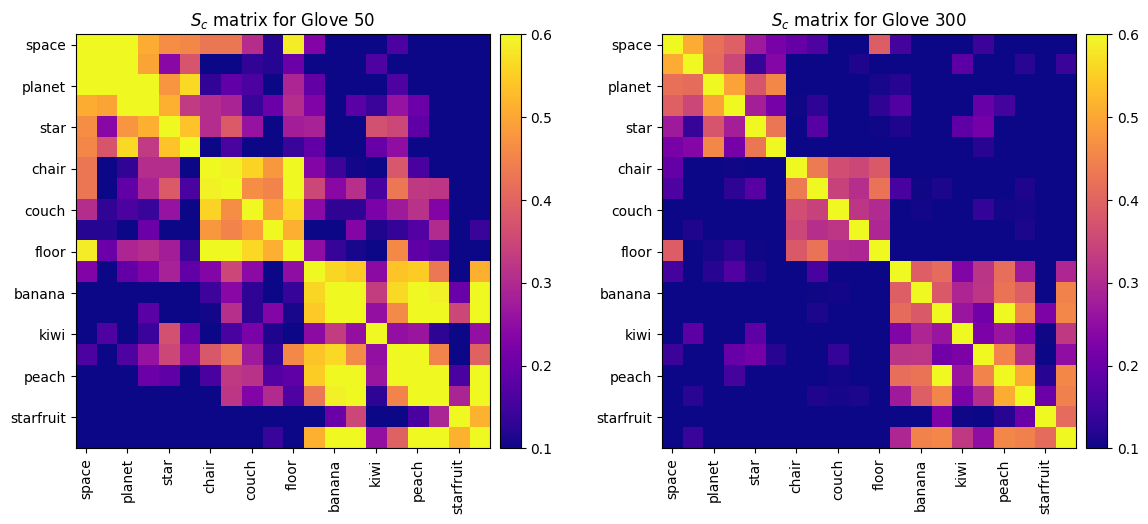

In [6]:
# Calculate and visualize the cosine similarity metrics for the two models
cosine_similarity_50 = cosine_similarity(embed_50)
cosine_similarity_300 = cosine_similarity(embed_300)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im = axs[0].imshow(cosine_similarity_50, cmap='plasma', interpolation='nearest', vmin=.1, vmax=.6)
axs[0].set_xticks(np.arange(0, len(words), 2))
axs[0].set_yticks(np.arange(0, len(words), 2))
axs[0].set_xticklabels(words[::2], rotation=90)
axs[0].set_yticklabels(words[::2])
axs[0].set_title('$S_c$ matrix for Glove 50')
fig.colorbar(im, ax=axs[0], pad=0.02)

im = axs[1].imshow(cosine_similarity_300, cmap='plasma', interpolation='nearest', vmin=.1, vmax=.6)
axs[1].set_xticks(np.arange(0, len(words), 2))
axs[1].set_yticks(np.arange(0, len(words), 2))
axs[1].set_xticklabels(words[::2], rotation=90)
axs[1].set_yticklabels(words[::2])
axs[1].set_title('$S_c$ matrix for Glove 300')
fig.colorbar(im, ax=axs[1], pad=0.02)

plt.tight_layout()
plt.show()

# Category Selectivity Index

In [7]:
np.arange(11,19)

array([11, 12, 13, 14, 15, 16, 17, 18])

In [8]:
# Create categories from the word list
categories = {
    'space': np.arange(0,6),
    'furniture': np.arange(6,11),
    'fruits': np.arange(11,20)
}

In [9]:
# Function to calculate the cosine similarities within and between categories
def category_selectivity_index(embedding, category):
    S = cosine_similarity(embedding)
    n = S.shape[0]

    csi = np.zeros(n)

    for cat_idx in categories.values():
      cat_idx = np.array(cat_idx)

      for i in cat_idx:
        # within category similarities
        within_cat = S[i, cat_idx]
        within_cat = within_cat[cat_idx != i]

        within_category_similarity = np.mean(within_cat)

        # between category similarities
        between_cat = np.setdiff1d(np.arange(n), cat_idx)
        between_cat_similarities = S[i, between_cat]

        between_category_similarity = np.mean(between_cat_similarities)

        csi[i] = within_category_similarity / between_category_similarity

    return csi, S

In [10]:
csi_50, S50 = category_selectivity_index(embed_50, categories)
csi_300, S300 = category_selectivity_index(embed_300, categories)

print(f'Mean CSI for Glove 50: {np.mean(csi_50)}')
print(f'Mean CSI for Glove 300: {np.mean(csi_300)}')

Mean CSI for Glove 50: 6.721957522630691
Mean CSI for Glove 300: 14.240202695131302


In [11]:
for name, idx in categories.items():
    print(f"{name}:")
    print("  GloVe-50 :", np.mean(csi_50[idx]))
    print("  GloVe-300:", np.mean(csi_300[idx]))

space:
  GloVe-50 : 17.57295306523641
  GloVe-300: 16.048309087753296
furniture:
  GloVe-50 : 3.600437641143799
  GloVe-300: 16.639833450317383
fruits:
  GloVe-50 : 1.2221382061640422
  GloVe-300: 11.701670236057705


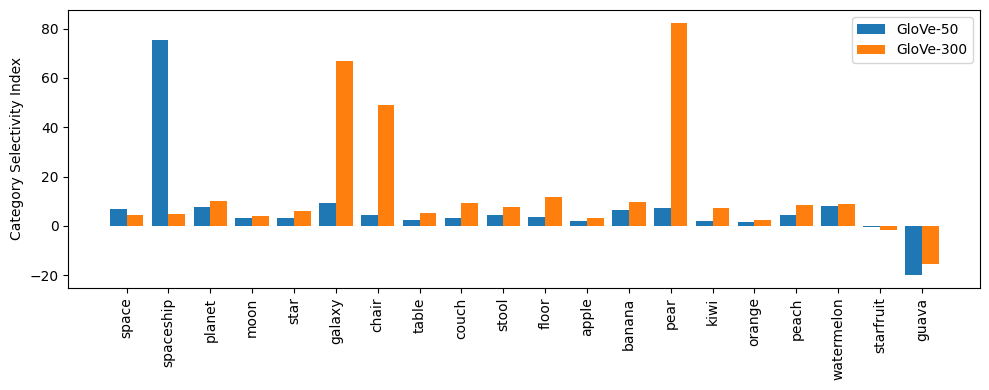

In [12]:
plt.figure(figsize=(10,4))
x = np.arange(len(words))

plt.bar(x - 0.2, csi_50, width=0.4, label="GloVe-50")
plt.bar(x + 0.2, csi_300, width=0.4, label="GloVe-300")

plt.xticks(x, words, rotation=90)
plt.ylabel("Category Selectivity Index")
plt.legend()
plt.tight_layout()
plt.show()


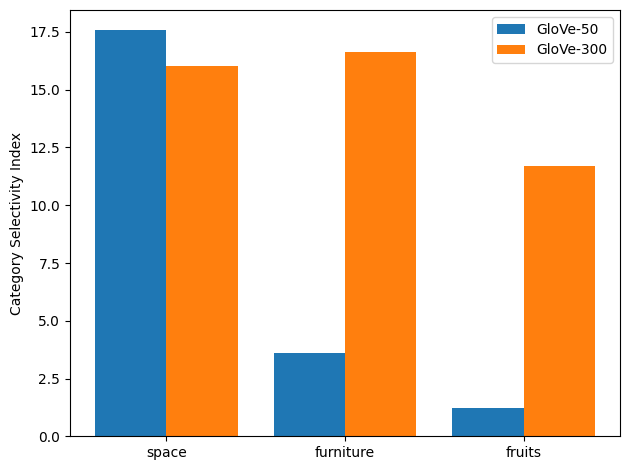

In [13]:
# Visualize average CSI per category
cat_names = list(categories.keys())

cat_csi_50 = [np.mean(csi_50[idx]) for idx in categories.values()]
cat_csi_300 = [np.mean(csi_300[idx]) for idx in categories.values()]

x = np.arange(len(cat_names))

plt.bar(x-0.2, cat_csi_50, width=0.4, label="GloVe-50")
plt.bar(x+0.2, cat_csi_300, width=0.4, label="GloVe-300")

plt.xticks(x, cat_names)
plt.ylabel("Category Selectivity Index")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
idx = np.triu_indices_from(S50, k=1)
unique_50 = S50[idx]

idx = np.triu_indices_from(S300, k=1)
unique_300 = S300[idx]

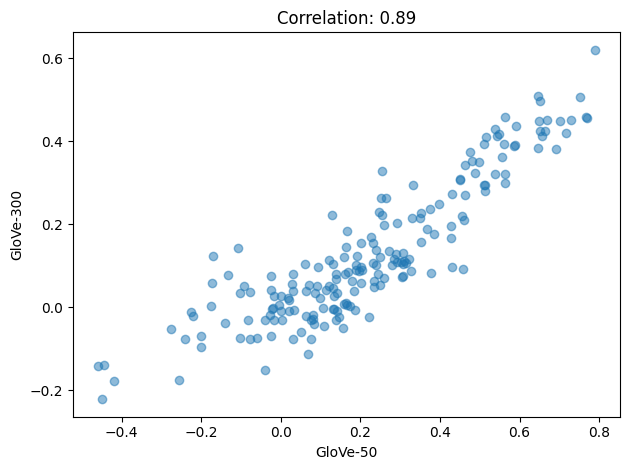

In [15]:
# Plot a scatter plot with cosine similarities for 50D and 30D embeddings matrices
corr = np.corrcoef(unique_50, unique_300)[0, 1]
plt.scatter(unique_50, unique_300, alpha=0.5)
plt.xlabel("GloVe-50")
plt.ylabel("GloVe-300")
plt.title(f"Correlation: {corr:.2f}")

plt.tight_layout()
plt.show()

# tSNE and DBSCAN

In [163]:
# Function to measure the tSNE and DBSCAN for the embeddings

from sklearn.preprocessing import StandardScaler

def tSNE_DBSCAN(embedding, randomize=None):

  tsne_results = TSNE(n_components=2, perplexity=5, learning_rate=200, random_state=randomize).fit_transform(embedding)

  X = StandardScaler().fit_transform(tsne_results)

  clustmodel = DBSCAN(eps=0.5, min_samples=4).fit(X)

  groupidx = clustmodel.labels_

  nclust = len(set(groupidx)) - (1 if -1 in groupidx else 0)

  # Get the centorids of the DBSCAN cluster

  centroids = {}

  for lab in sorted(set(groupidx)):
    if lab == -1:
      continue
    pts = tsne_results[groupidx == lab]
    centroids[lab] = pts.mean(axis=0)

  return tsne_results, (clustmodel, groupidx, nclust, centroids)



In [168]:
# DBSCAN for 50D and 300D embeddings
randomize = None
tsne_50, db50 = tSNE_DBSCAN(embed_50, randomize=randomize)
tsne_300, db300 = tSNE_DBSCAN(embed_300, randomize=randomize)

In [169]:
# function to plot DBSCAN results (label each point + named clusters in legend)

def plot_dbscan(ax, tsne_xy, dbscan_tuple, title,
                words=None,
                cluster_names=None,
                draw_lines=False,
                text_offset=(4, 4)):

    clustmodel, groupidx, nclust, centroids = dbscan_tuple
    lineColors = "rkgbmcy"

    if words is None:
        # fallback: numeric labels
        words = [str(i) for i in range(len(tsne_xy))]

    # default cluster names if none provided
    # (customize these as you like)
    if cluster_names is None:
        cluster_names = {
            0: "Cluster 0",
            1: "Cluster 1",
            2: "Cluster 2",
        }

    # --- Plot noise (label -1) once ---
    noise_mask = (groupidx == -1)
    if np.any(noise_mask):
        ax.plot(tsne_xy[noise_mask, 0], tsne_xy[noise_mask, 1],
                'k+', label="Noise / Unclustered")

    # --- Plot each cluster separately (one legend entry per cluster) ---
    for k in range(nclust):
        mask = (groupidx == k)
        if not np.any(mask):
            continue

        name = cluster_names.get(k, f"Cluster {k}")

        ax.plot(tsne_xy[mask, 0], tsne_xy[mask, 1],
                'o',
                markerfacecolor=lineColors[k % len(lineColors)],
                markeredgecolor='k',
                label=name)

        # centroid (in tSNE space)
        if k in centroids:
            c = centroids[k]
            ax.plot(c[0], c[1], 'X', markersize=10,
                    markeredgecolor='k', markerfacecolor='none')

            # optional: draw lines from points to centroid
            if draw_lines:
                for x, y in tsne_xy[mask]:
                    ax.plot([x, c[0]], [y, c[1]],
                            lineColors[k % len(lineColors)],
                            alpha=0.35, linewidth=1)

    # --- Label individual points ---
    for i, (x, y) in enumerate(tsne_xy):
        ax.annotate(
            words[i],
            (x, y),
            textcoords="offset points",
            xytext=text_offset,
            ha="left",
            fontsize=9
        )

    ax.set(xlabel="tSNE axis 1", ylabel="tSNE axis 2", title=title)
    ax.margins(0.25)
    ax.legend(loc="best", fontsize=9)


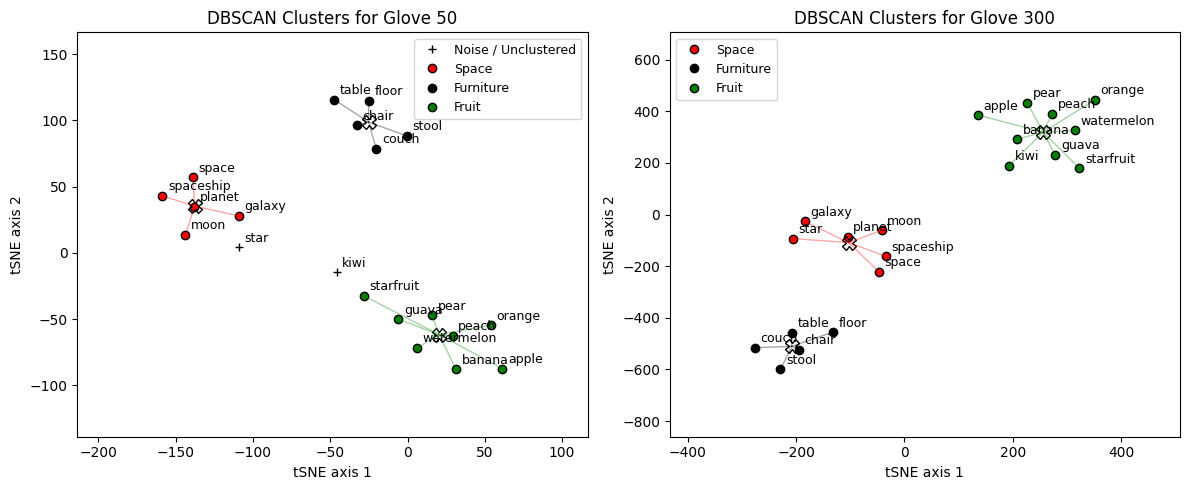

In [170]:
cluster_names={
    0: "Space",
    1: "Furniture",
    2: "Fruit"
}
fig, axs = plt.subplots(1,2, figsize=(12,5))
plot_dbscan(axs[0], tsne_50, db50, "DBSCAN Clusters for Glove 50", words=words, cluster_names=cluster_names, draw_lines=True)
plot_dbscan(axs[1], tsne_300, db300, "DBSCAN Clusters for Glove 300", words=words, cluster_names=cluster_names, draw_lines=True)
plt.tight_layout()
plt.show()

In [171]:
for i, groupidx in enumerate([db50[1], db300[1]]):
  print(f'\n**Clusters for {[50,300][i]}D embeddings:**')

  unclustered_word_indices = np.where(groupidx == -1)[0]
  if len(unclustered_word_indices) > 0:
    print(f'Unclustered word: {', '.join([words[t] for t in unclustered_word_indices])}')

  for lab in set(groupidx):
    if lab == -1:
      continue
    else:
      words_in_clust = np.where(groupidx == lab)[0]
      print(f'Cluster {lab}: [{', '.join([words[t] for t in words_in_clust])}]')


**Clusters for 50D embeddings:**
Unclustered word: star, kiwi
Cluster 0: [space, spaceship, planet, moon, galaxy]
Cluster 1: [chair, table, couch, stool, floor]
Cluster 2: [apple, banana, pear, orange, peach, watermelon, starfruit, guava]

**Clusters for 300D embeddings:**
Cluster 0: [space, spaceship, planet, moon, star, galaxy]
Cluster 1: [chair, table, couch, stool, floor]
Cluster 2: [apple, banana, pear, kiwi, orange, peach, watermelon, starfruit, guava]
